<a href="https://colab.research.google.com/github/Abborse/Home-Automation-System-Development/blob/main/Linear_Regression_withoutcode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  <center><u>LINEAR REGRESSION<u><center>

<p style='text-align: right;'> Total points =51</p>


###  Linear Regression


Linear Regression is a statistical technique which is used to find the linear relationship between dependent and one or more independent variables. This technique is applicable for Supervised learning Regression problems where we try to predict a continuous variable.


Linear Regression can be further classified into two types – Simple and Multiple Linear Regression. It is the simplest form of Linear Regression where we fit a straight line to the data.



##Problem Statement
Build a model which predicts sales based on the money spent on different platforms for marketing.

Understanding the Data
Let's start with the following steps:

1. Importing data using the pandas library
2. Understanding the structure of the data

<p style='text-align: right;'> 2*2=4 points</p>


In [ ]:
# Import necessary libraries numpy as np, pandas as pd, pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## About the dataset

Let's import data from the following url:-

https://www.kaggle.com/ashydv/advertising-dataset








Data Dict:<br>
There are 3 Input Variables and 1 Output Variable (Sales).<br>
The data type of all the input variables is float64. The data type of out variable (Sales) is float64.<br>

In [ ]:
# Import the data

df = pd.read_csv('/content/advertising.csv')
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [ ]:
#drop radio and newspaper column
df = df.drop(['Radio','Newspaper'], axis=1)

### pandas shape attribute

The shape attribute of the pandas dataframe gives the dimensions of the dataframe.

In [ ]:
# View the dimensions of df

df.shape


(200, 2)

### pandas head() method


In [ ]:
# View the top 5 rows of df
df.head()


,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,12.0
3,151.5,16.5
4,180.8,17.9


### pandas info() method

In [ ]:
# View dataframe summary

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Sales   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


### pandas describe() method

In [ ]:
# View descriptive statistics

df.describe()


,TV,Sales
count,200.000000,200.000000
mean,147.042500,15.130500
std,85.854236,5.283892
min,0.700000,1.600000
25%,74.375000,11.000000
50%,149.750000,16.000000
75%,218.825000,19.050000
max,296.400000,27.000000


## Independent and Dependent Variables


### Independent variable

Independent variable is also called Input variable and is denoted by X. In practical applications, independent variable is also called Feature variable or Predictor variable. We can denote it as:-

Independent or Input variable (X) = Feature variable = Predictor variable


### Dependent variable

Dependent variable is also called Output variable and is denoted by y.

Dependent variable is also called Target variable or Response variable. It can be denoted it as follows:-

Dependent or Output variable (y) = Target variable = Response variable


<p style='text-align: right;'> 2 points</p>


In [ ]:
# Declare feature variable and target variable

# TV and Sales data values are given by X and y respectively.

# Values attribute of pandas dataframe returns the numpy arrays.

X = df['TV'].values

y = df['Sales'].values


In [ ]:
type(X)

numpy.ndarray

## Visual exploratory data analysis

Visualize the relationship between X and y by plotting a scatterplot between X and y.


<p style='text-align: right;'> 2 points</p>


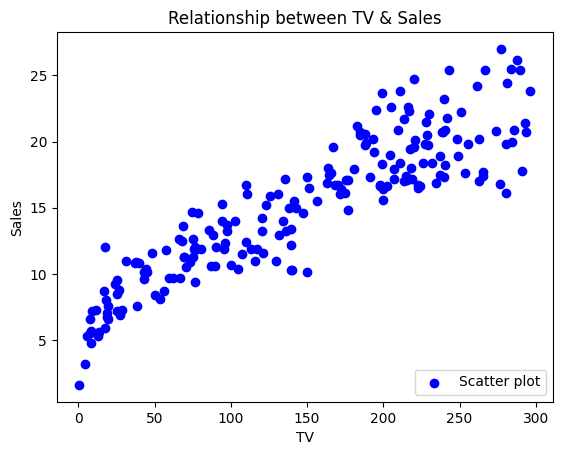

In [ ]:
# Plot scatter plot between X and y
plt.scatter(X,y,color='blue',label='Scatter plot')
plt.title('Relationship between TV & Sales')
plt.xlabel('TV')
plt.ylabel('Sales')
plt.legend(loc=4)
plt.show()

Hey buddy! did you notice ? the above graph shows some sort of relationship between sales and TV. Don't you think this shows positive linear relation? i.e when As TV's value increases sales increases ans same is vise-versa.

# Visualising Data Using Seaborn


<p style='text-align: right;'> 2*2=4 points</p>


In [ ]:
# import seaborn with alias sns
import seaborn as sns


# import %matplotlib inline to visualise in the notebook
%matplotlib inline

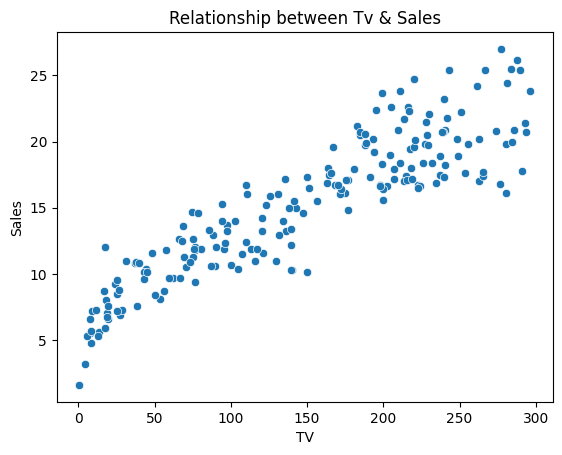

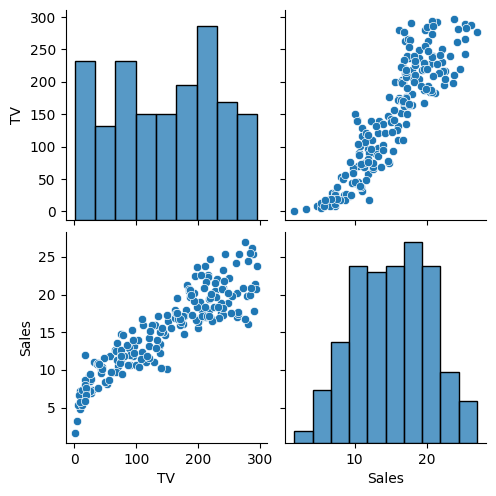

In [ ]:
# Visualise the relationship between the features and the response using scatterplots
sns.scatterplot(x='TV',y='Sales',data=df)
plt.title('Relationship between Tv & Sales')
plt.xlabel('TV')
plt.ylabel('Sales')
plt.show()

# plot a pairplot also for df

sns.pairplot(df)
plt.show()


## Checking dimensions of X and y

We need to check the dimensions of X and y to make sure they are in right format for Scikit-Learn API.


<p style='text-align: right;'> 2points</p>


In [ ]:
# Print the dimensions of X and y

print(X.shape)
print(y.shape)


(200,)
(200,)


## Reshaping X and y

Since we are working with only one feature variable, so we need to reshape using Numpy reshape() method.

E.g, If you have an array of shape (3,2) then reshaping it with (-1, 1), then the array will get reshaped in such a way that the resulting array has only 1 column and this is only possible by having 6 rows, hence, (6,1)

You have seen the above example. Now you smarty! try reshaping on your data.

<p style='text-align: right;'> 2*2 = 4 points</p>


In [ ]:
# Reshape X and y

X = X.reshape(-1,1)

y = y.reshape(-1,1)



In [ ]:
# Print the dimensions of X and y after reshaping
print(X.shape)
print(y.shape)



(200, 1)
(200, 1)


Cool right!

## Difference in dimensions of X and y after reshaping


Hey! You can see the difference in diminsions of X and y before and after reshaping.

It is essential in this case because getting the feature and target variable right is an important precursor to model building.

# Performing Simple Linear Regression

Equation of linear regression<br>
$y = c + m_1x_1 + m_2x_2 + ... + m_nx_n$

-  $y$ is the response
-  $c$ is the intercept
-  $m_1$ is the coefficient for the first feature
-  $m_n$ is the coefficient for the nth feature<br>

In our case:

$y = c + m_1 \times TV$

The $m$ values are called the model **coefficients** or **model parameters**.


## Mechanics of the model

Hey! before you read further, it is good to understand the generic structure of modeling using the scikit-learn library. Broadly, the steps to build any model can be divided as follows:

Split the dataset into two sets – the training set and the test set. Then, instantiate the regressor lm and fit it on the training set with the fit method.

In this step, the model learned the relationships between the training data (X_train, y_train).

Oh Yeah! Now the model is ready to make predictions on the test data (X_test). Hence, predict on the test data using the predict method.


The steps are as follow:

## Train test split


Split the dataset into two sets namely - train set and test set.

The model learn the relationships from the training data and predict on test data.


In [ ]:
# import train test split
from sklearn.model_selection import train_test_split

# Split X and y into training and test data sets

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)


In [ ]:
# print shapes of X_train,y_train, X_test, y_test
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(140, 1)
(140, 1)
(60, 1)
(60, 1)


In [ ]:
# Fit the linear model
from sklearn.linear_model import LinearRegression
# Instantiate the linear regression object lm

lm = LinearRegression()


# Train the model using training data sets
lm.fit(X_train,y_train)



# Predict on the test data
y_pred =lm.predict(X_test)

## Model slope and intercept term

The model slope is given by lm.coef_ and model intercept term is given by lm.intercept_.

for example. if the estimated model slope and intercept values are 1.60509347 and  -11.16003616.

So, the equation of the fitted regression line will be:-

y = 1.60509347 * x - 11.16003616  



<p style='text-align: right;'> 2 points</p>


In [ ]:
# Compute model slope and intercept

a = lm.coef_
b = lm.intercept_

# also print a and b
print("Estimated model Slope: ",a)
print("Estimated model intercept: ",b)

Estimated model Slope:  [[0.05483488]]
Estimated model intercept:  [7.20655455]


In [ ]:
# So comment below, our fitted regression line here is ?

y=0.05483488 * X + 7.20655455

# That is our linear model.

Wohoo! Awesome job done!

## Making predictions


To make prediction, on an individual TV value,


		lm.predict(Xi)
        

where Xi is the TV data value of the ith observation.



In [ ]:
lm.predict(X[0:5])

array([[19.82406131],
       [ 9.64670688],
       [ 8.14971455],
       [15.51403944],
       [17.12070154]])

<p style='text-align: right;'> 2 points</p>


In [ ]:
# Predicting Sales values on first five 5 TV  datasets only

lm.predict(X[0:5])



array([[19.82406131],
       [ 9.64670688],
       [ 8.14971455],
       [15.51403944],
       [17.12070154]])

We know that you can also do prediction for all values of TV available in our dataset

Can you show it now?



In [ ]:
# prediction for all X present in the dataset

lm.predict(X)


array([[19.82406131],
       [ 9.64670688],
       [ 8.14971455],
       [15.51403944],
       [17.12070154],
       [ 7.68361804],
       [10.35956037],
       [13.79770758],
       [ 7.67813455],
       [18.16256433],
       [10.83114037],
       [18.9796041 ],
       [ 8.51162478],
       [12.55295572],
       [18.39835433],
       [17.92129084],
       [10.92435967],
       [22.63709085],
       [11.00112851],
       [15.28373293],
       [19.18249317],
       [20.22435596],
       [ 7.93037501],
       [19.72535852],
       [10.62276781],
       [21.6226455 ],
       [15.04245944],
       [20.37241015],
       [20.84947364],
       [11.07789734],
       [23.26769201],
       [13.39741293],
       [12.53650525],
       [21.77069968],
       [12.45425293],
       [23.14705527],
       [21.84198503],
       [11.30272037],
       [ 9.56993804],
       [19.70890805],
       [18.31061852],
       [16.91232898],
       [23.30607643],
       [18.55189201],
       [ 8.58291013],
       [16

## Regression metrics for model performance


Now, it is the time to evaluate model performance.

For regression problems, there are two ways to compute the model performance. They are RMSE (Root Mean Square Error) and R-Squared Value. These are explained below:-  


### RMSE

    RMSE is the standard deviation of the residuals. So, RMSE gives us the standard deviation of the unexplained variance by the model. It can be calculated by taking square root of Mean Squared Error.
    RMSE is an absolute measure of fit. It gives us how spread the residuals are, given by the standard deviation of the residuals. The more concentrated the data is around the regression line, the lower the residuals and hence lower the standard deviation of residuals. It results in lower values of RMSE. So, lower values of RMSE indicate better fit of data.

Formula:
![image.png](attachment:image.png)



### R-Squared

    (R2) Correlation explains the strength of the relationship between an independent and dependent variable,whereas R-square explains to what extent the variance of one variable explains the variance of the second variable. Hence It may also be known as the coefficient of determination.
    So, if the R2 of a model is 0.50, then approximately half of the observed variation can be explained by the model's inputs.
    In general, the higher the R2 Score value, the better the model fits the data. Usually, its value ranges from 0 to 1. So, we want its value to be as close to 1. Its value can become negative if our model is wrong.

Fomula:

![image.png](attachment:image.png)

<p style='text-align: right;'> 2*2 = 4 points</p>




Read this blog for metrics in regression: https://machinelearningmastery.com/regression-metrics-for-machine-learning/

In [ ]:
# Calculate and print Root Mean Square Error(RMSE)
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
print("RMSE value : {:.4f}".format(rmse))

RMSE value: 2.2759


In [ ]:
# Calculate and print r2_score
from sklearn.metrics import r2_score
print("r2 Score value : {:.4f}".format(r2_score(y_test,y_pred)))



r2 Score value : 0.8149


## Interpretation and Conclusion


The RMSE value has been found to be  2.2759. It means the standard deviation for our prediction is  2.2759. which is quite less. Sometimes we can also expect the RMSE to be less than  2.2759. So, the model is good fit to the data.


In business decisions, the benchmark for the R2 score value is 0.7. It means if R2 score value >= 0.7, then the model is good enough to deploy on unseen data whereas if R2 score value < 0.7, then the model is not good enough to deploy. Our R2 score value has been found to be  0.8149. It means that this model explains  81.49 % of the variance in our dependent variable. So, the R2 score value confirms that the model is good enough to deploy because it provides good fit to the data.

Wohoo! Really good job done!

<p style='text-align: right;'> 2 points</p>


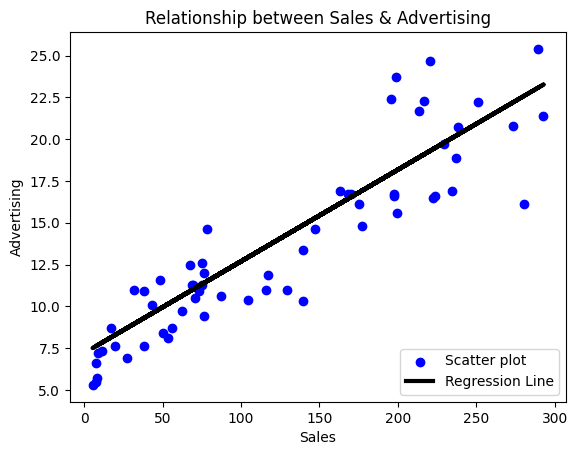

In [ ]:
# Plot the Regression Line between X and Y as shown in below output.
plt.scatter(X_test,y_test,color='blue',label='Scatter plot')
plt.plot(X_test,y_pred,color='black',linewidth=3,label='Regression Line')
plt.title('Relationship between Sales & Advertising')
plt.xlabel('Sales')
plt.ylabel('Advertising')
plt.legend(loc=4)
plt.show()





As you can see above, the regression line fits the data quite well. Wow!

## Residual analysis



A linear regression model may not represent the data appropriately. The model may be a poor fit to the data. So, we should validate our model by defining and examining residual plots.

The difference between the observed value of the dependent variable (y) and the predicted value (ŷi) is called the residual and is denoted by e or error. The scatter-plot of these residuals is called residual plot.

If the data points in a residual plot are randomly dispersed around horizontal axis and an approximate zero residual mean, a linear regression model may be appropriate for the data. Otherwise a non-linear model may be more appropriate.

If we take a look at the generated ‘Residual errors’ plot, we can clearly see that the train data plot pattern is non-random. Same is the case with the test data plot pattern.
So, it suggests a better-fit for a non-linear model.



# **`Summary`**

- We learnt assumptions required for linear regression model.
- We built linear regression model using sklearn and also got the basic idea of overfitting and underfitting.
- We also did residual analysis to cross check one of the linear regression assumption.

#  Congratulations on building your first machine learning model! # From Er. Saurabh Kalal Sir